In [ ]:
import os
import pandas as pd
import numpy as np
path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

/opt/anaconda3/envs/accidents/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.74      0.76      0.75     65070
           2       0.68      0.48      0.56     61671
           3       0.39      0.40      0.39     23801
           4       0.13      0.61      0.21      4110

    accuracy                           0.59    154652
   macro avg       0.48      0.56      0.48    154652
weighted avg       0.65      0.59      0.61    154652



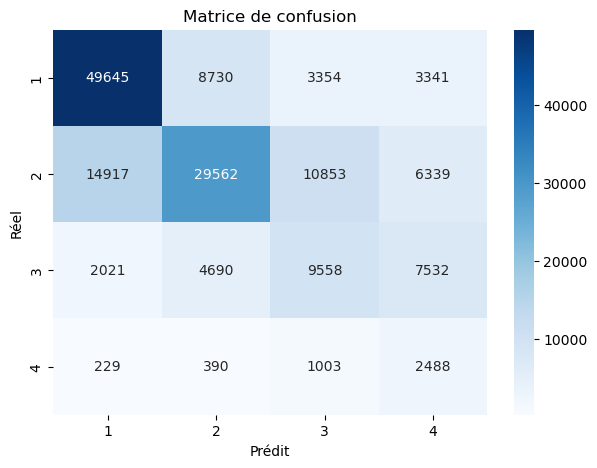

In [2]:
##############
# Logistic Regression with under-sampling and smoothing on target encoding
##############
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline  # Pour compatibilité SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Importation des données

path = os.path.join( "..", "data", "processed", "accidents_preprocessed_v3.csv")
df = pd.read_csv(path)

# === 1. Split data
X = df.drop(columns=['grav'])  
y = df['grav']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f'eq_{str(c)}' for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f'eq_{str(c)}' for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns='equipements'), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns='equipements'), equip_test], axis=1)



# Colonnes
equip_cols = list(equip_train.columns)
cols_to_exclude = ['dep'] + equip_cols
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

# Préprocesseur combiné
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe),
    ('target_enc', TargetEncoder(smoothing=10, min_samples_leaf=1), ['dep'])
], remainder='passthrough')



pipeline = ImbPipeline(steps=[
    ('encoding', preprocessor),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, multi_class='multinomial'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred))


# --- Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())  
# --- Affichage
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

In [ ]:
####################################################################
# DNN sur version v3 du feature engineering (sans communes, avec dep, et toutes les variables pas significatives)
####################################################################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed_v3.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "dep" avec TargetEncoder
te = TargetEncoder()
X_train["dep_encoded"] = te.fit_transform(X_train["dep"], y_train)
X_test["dep_encoded"] = te.transform(X_test["dep"])
X_train.drop(columns="dep", inplace=True)
X_test.drop(columns="dep", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['dep_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction
y_pred = np.argmax(model.predict(X_test_processed), axis=1)

# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()
